In [7]:
# %%
import sys
sys.path.insert(0, '..')
import helper_functions
from constants import *

import eelbrain
import numpy as np
import mne
import matplotlib.gridspec as gridspec
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from matplotlib.gridspec import GridSpecFromSubplotSpec

In [8]:
# %%
SUBJECTS = helper_functions.get_subjects()

checks = [
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD, False),
]

# Latencies (seconds) per model
latencies = {
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): [-0.180, -0.140, -0.075],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): [-0.180, -0.140, -0.075],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): [-0.250, -0.140, -0.080],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): [-0.250, -0.140, -0.080],
}

colors = {
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:blue',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:orange',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:green',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:red',
}

In [9]:
# %%
trf_data, n_subjects = helper_functions.load_trfs(checks, trf_dir=MAT_FILE_TRF_DIR)

# Compute grand mean TRFs
backward_trfs = {}
for predictor, attention, model, padded in checks:
    model_name = helper_functions.get_trf_model_name(predictor, attention, model, padded)
    trf_list   = [trf.h_scaled[0] if isinstance(trf.h_scaled, tuple) else trf.h_scaled 
                  for trf in trf_data[model_name]]
    backward_trfs[model_name] = eelbrain.combine(trf_list).mean('case')
    print(f"  ✓ Grand mean computed ({len(trf_list)} subjects)")

  ✓ S1
  ✓ S2
  ✓ S3
  ✓ S4
  ✓ S5
  ✓ S6
  ✓ S7
  ✓ S8
  ✓ S9
  ✓ S10
  ✓ S11
  ✓ S12
  ✓ S13
  ✓ S14
  ✓ S15
  ✓ S16
  ✓ S17
  ✓ S18

Loaded: 18 subjects | Skipped: 0 subjects
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)


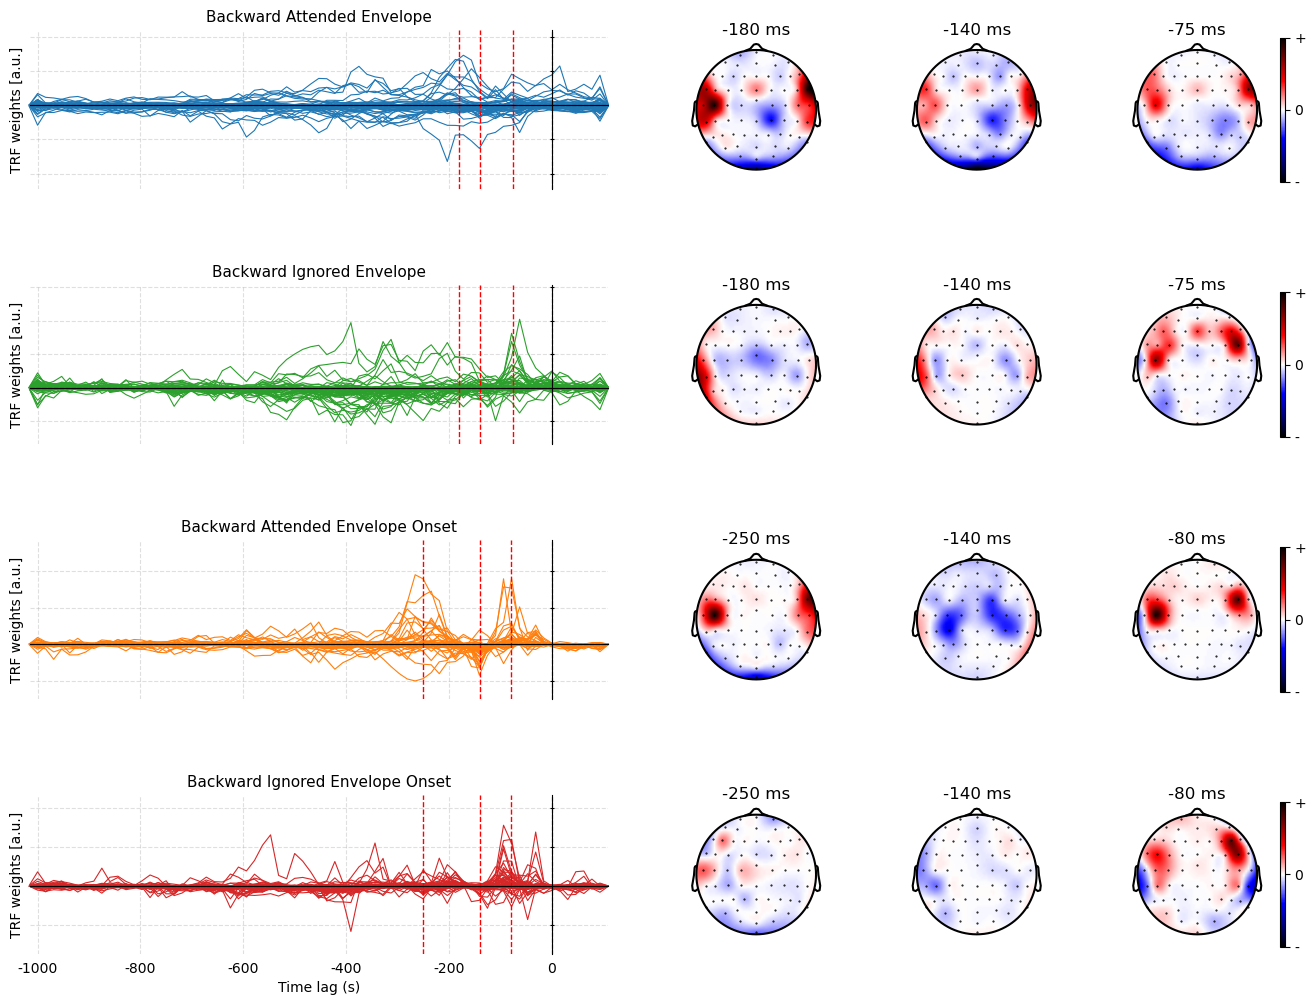

In [10]:
fig = plt.figure(figsize=(16, 3 * len(checks)))
n_rows = len(checks)
max_topos = 3

gs = fig.add_gridspec(
    n_rows,
    1 + max_topos,
    width_ratios=[4] + [1] * max_topos,
    hspace=0.6,
    wspace=0.3
)

for i, (predictor, attention, model, padded) in enumerate(checks):
    model_name = helper_functions.get_trf_model_name(predictor, attention, model, padded)
    trf        = backward_trfs[model_name]
    trf_vmax   = trf.max()
    trf_plot   = trf.mean('predictor') if 'predictor' in trf.dims else trf
    lats       = latencies[model_name]

    # ======================
    # A) Butterfly TRF (left)
    # ======================
    ax_trf = fig.add_subplot(gs[i, 0])

    eelbrain.plot.Butterfly(
        trf_plot,
        axes=ax_trf,
        color=colors[model_name],
        linewidth=0.8,
        frame='t',
        yticklabels='none',
        ylabel='TRF weights [a.u.]',
        xlabel='Time lag (s)' if i == n_rows - 1 else '',
        xticklabels='none' if i < n_rows - 1 else True,
    )
    mean_trf = np.array(trf_plot.x).mean(axis=0)
    #time_s = np.array(trf_plot.time.times)
    #ax_trf.plot(time_s, mean_trf, color='black', linewidth=2.0, zorder=5)

    y_min = trf_plot.x.min()
    y_max = trf_plot.x.max()
    ax_trf.set_ylim(y_min * 1.5, y_max * 1.5)

    for t in lats:
        ax_trf.axvline(t, color='red', linestyle='--', linewidth=1)

    ax_trf.axhline(0, linestyle='--', color='black', linewidth=0.8)
    ax_trf.axvline(0, linestyle='--', color='black', linewidth=0.8)
    ax_trf.grid(True, linestyle='--', alpha=0.4)
    ax_trf.set_title(model_name.replace('_', ' ').title(), fontsize=11)

    # ======================
    # B) Topomaps (right)
    # ======================
    topo_axes = [fig.add_subplot(gs[i, 1 + j]) for j in range(len(lats))]
    t_labels  = ['%d ms' % (t * 1000) for t in lats]

    plot_topo = eelbrain.plot.Topomap(
        [trf_plot.sub(time=t) for t in lats],
        axes=topo_axes,
        axtitle=t_labels,
        columns=max_topos,
        vmax=trf_vmax,
        clip='circle',
    )
    plot_topo.plot_colorbar(right_of=topo_axes[-1], label='', label_rotation=90, ticks={trf_vmax:'+', -trf_vmax:'-', 0:'0'})

fig.savefig(FIGURES_DIR / f'{FUGLSANG}-backward-trf.pdf', bbox_inches='tight')
plt.show()